<a href="https://colab.research.google.com/github/sydas13/ML_Lab_Codes/blob/main/Question2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [115]:
from google.colab import files

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [117]:
uploaded = files.upload()

Saving Housing.csv to Housing (1).csv


In [118]:
data = pd.read_csv("Housing.csv")

print("=== House Price Dataset ===")
print(data.head(), "\n")
print("Columns:", list(data.columns), "\n")


=== House Price Dataset ===
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished   

Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainr

In [119]:
X = data.drop('price', axis=1)
y = data['price']

In [120]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
multi_cat_cols = ['furnishingstatus']
numeric_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

In [121]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('bin', OneHotEncoder(drop='if_binary'), binary_cols),
        ('multi', OneHotEncoder(drop='first'), multi_cat_cols)
    ]
)

In [122]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [123]:
lasso = Pipeline(steps=[('preprocessor', preprocessor),
                        ('model', Lasso(max_iter=10000, random_state=42))])

ridge = Pipeline(steps=[('preprocessor', preprocessor),
                        ('model', Ridge(random_state=42))])

In [124]:
lasso_params = {'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
ridge_params = {'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

lasso_grid = GridSearchCV(lasso, lasso_params, cv=5, scoring='r2')
ridge_grid = GridSearchCV(ridge, ridge_params, cv=5, scoring='r2')

lasso_grid.fit(X_train, y_train)
ridge_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         'passthrough',
                                                                         ['area',
                                                                          'bedrooms',
                                                                          'bathrooms',
                                                                          'stories',
                                                                          'parking']),
                                                                        ('bin',
                                                                         OneHotEncoder(drop='if_binary'),
                                                                         ['mainroad',
                                                                          'guestroom',
                                                                          'basement',
                                                                          'hotwaterheating',
                                                                          'airconditioning',
                                                                          'prefarea']),
                                                                        ('multi',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['furnishingstatus'])])),
                                       ('model', Ridge(random_state=42))]),
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [125]:
best_lasso = lasso_grid.best_estimator_
best_ridge = ridge_grid.best_estimator_

print("Best Lasso α:", lasso_grid.best_params_)
print("Best Ridge α:", ridge_grid.best_params_, "\n")

Best Lasso α: {'model__alpha': 100}
Best Ridge α: {'model__alpha': 10} 



In [126]:
y_pred_lasso = best_lasso.predict(X_test)
y_pred_ridge = best_ridge.predict(X_test)

In [127]:
def evaluate_model(name, y_test, y_pred):
    print(f"=== {name} Evaluation ===")
    print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
    print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}\n")

evaluate_model("Lasso Regression", y_test, y_pred_lasso)
evaluate_model("Ridge Regression", y_test, y_pred_ridge)

=== Lasso Regression Evaluation ===
R² Score: 0.6529
MSE: 1754577268906.34
MAE: 970086.29

=== Ridge Regression Evaluation ===
R² Score: 0.6482
MSE: 1778202744652.58
MAE: 971533.45



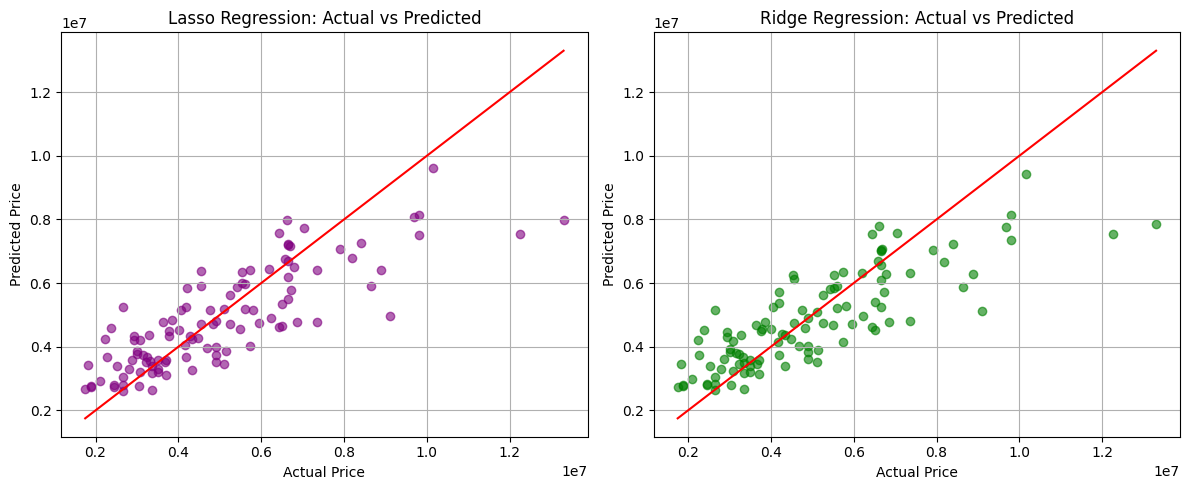

In [128]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_lasso, color='purple', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.title("Lasso Regression: Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid(True)

plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_ridge, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.title("Ridge Regression: Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid(True)

plt.tight_layout()
plt.show()